# EURUSD — Buy Model (Y₁) · v2

**Purpose:** Train the binary BUY sub-model for EURUSD on the H1 timeframe.
The label asks: *"would a long trade have hit Take Profit before Stop Loss in the next N bars?"*

**Pipeline overview:**
1. Configuration (paths, ATR params, split dates)
2. Load raw H1 data
3. Validate & inspect the dataset
4. Feature engineering (technical indicators) → `df_features`
5. ATR threshold tuning (class balance exploration on training window)
6. Label generation (SL/TP path-dependent labels) → `df_labeled`
7. Chronological split → `df_train` / `df_val` / `df_test`
8. Walk-forward training — XGBoost + LightGBM base models
9. Evaluation (cost-aware metrics)
10. Save trained model to `models_bin/`

---
### v2 improvements applied
| # | Change | Why |
|---|---|---|
| REC 1 | Ambiguous same-bar TP+SL hits → excluded (NaN) not forced label=0 | False negatives capped precision ceiling |
| REC 2 | Threshold selected by **precision margin** not max recall + test cross-check | Loosest threshold is most fragile |
| REC 3 | `ATR_TP_MULT` = 2.0 (breakeven = 33.3% not 36.4%) | Wider R:R lowers the bar the model must clear |
| REC 4 | Probability calibration via `CalibratedClassifierCV(isotonic)` | Raw LightGBM probs are not calibrated |
| REC 5 | `fillna(0)` → `SimpleImputer(median)` fit on train only | 0 is a meaningful value for z-scored features |

In [1]:
# NOTE: REVIEW — Isotonic calibration on a small 15% holdout with an
# imbalanced class distribution may overfit the calibration itself.
# If the model's uncalibrated probabilities at high thresholds already
# produce usable precision, the complexity may not be worth the reduced
# training data. Consider testing with and without this cell.
# imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# REC 4 + REC 5 — new imports added in v2
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

Python  : 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)]
NumPy   : 2.2.6
Pandas  : 2.3.1


## 1. Configuration

All paths and key parameters live in one place.
Change `PAIR` or `TIMEFRAME` here to reuse this notebook for other instruments.

In [2]:
from pathlib import Path

# ── Instrument & timeframe ────────────────────────────────────────────────────
PAIR      = "EURUSD"
TIMEFRAME = "H1"

# ── Data paths ────────────────────────────────────────────────────────────────
ROOT = Path("../..").resolve()

RAW_DATA_DIR = ROOT / "data" / "raw" / "mt5" / TIMEFRAME
RAW_FILE     = RAW_DATA_DIR / f"{PAIR}_{TIMEFRAME}.csv"

MODELS_DIR = ROOT / "models_bin"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Label parameters ──────────────────────────────────────────────────────────
# REC 3: ATR_TP_MULT=2.0 -> breakeven = SL/(TP+SL) = 1/(2+1) = 33.3%
# (was 1.75 -> breakeven 36.4%  — widening R:R lowers the bar the model must clear)
ATR_PERIOD   = 14    # bars used to compute ATR(14)
ATR_TP_MULT  = 1.5   # take-profit distance = ATR × ATR_TP_MULT
ATR_SL_MULT  = 1.0   # stop-loss distance   = ATR × ATR_SL_MULT
FORWARD_BARS = 10     # how many H1 bars forward to scan for TP/SL hit

# ── Chronological split boundaries ───────────────────────────────────────────
TRAIN_START = "2019-01-01"
TRAIN_END   = "2025-06-30 23:00:00"
VAL_START   = "2025-07-01 00:00:00"
VAL_END     = "2026-01-30 23:00:00"
TEST_START  = "2026-02-01 00:00:00"

# ── Breakeven precision ───────────────────────────────────────────────────────
breakeven = ATR_SL_MULT / (ATR_TP_MULT + ATR_SL_MULT)

print(f"Pair       : {PAIR}")
print(f"Timeframe  : {TIMEFRAME}")
print(f"Raw file   : {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")
print(f"Train      : {TRAIN_START}  ->  {TRAIN_END}")
print(f"Val        : {VAL_START}  ->  {VAL_END}")
print(f"Test       : {TEST_START}  ->  present")
print(f"Breakeven  : {breakeven:.4f}  ({breakeven*100:.1f}%)")

Pair       : EURUSD
Timeframe  : H1
Raw file   : C:\Users\dsosa\Documents\fx-prival\ml-signal-service\data\raw\mt5\H1\EURUSD_H1.csv
File exists: True
Train      : 2019-01-01  ->  2025-06-30 23:00:00
Val        : 2025-07-01 00:00:00  ->  2026-01-30 23:00:00
Test       : 2026-02-01 00:00:00  ->  present
Breakeven  : 0.4000  (40.0%)


## 2. Load Raw Data

Load the MT5 H1 export for EURUSD. The file contains: `datetime, open, high, low, close, volume`.

In [3]:
df = pd.read_csv(
    RAW_FILE,
    parse_dates=["datetime"],
)

df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows      : {len(df):,}")
print(f"Columns   : {list(df.columns)}")
print(f"Date range: {df['datetime'].min()}  →  {df['datetime'].max()}")

Rows      : 46,697
Columns   : ['datetime', 'open', 'high', 'low', 'close', 'volume']
Date range: 2019-01-02 00:00:00  →  2026-07-03 15:00:00


## 3. Validate the Dataset

Quick sanity checks:
- **dtypes** — datetime must be a proper timestamp, OHLCV must be numeric
- **nulls** — no missing values allowed before feature engineering
- **OHLC logic** — high ≥ open/close ≥ low for every bar
- **Duplicates** — no repeated timestamps

In [4]:
print("=== dtypes ===")
print(df.dtypes)

print("\n=== Null values per column ===")
print(df.isnull().sum())

n_dupes = df["datetime"].duplicated().sum()
print(f"\nDuplicate timestamps : {n_dupes}")

bad_ohlc = df[
    (df["high"] < df["open"])  |
    (df["high"] < df["close"]) |
    (df["low"]  > df["open"])  |
    (df["low"]  > df["close"])
]
print(f"OHLC logic violations: {len(bad_ohlc)}")

print("\n=== Descriptive statistics ===")
df[["open", "high", "low", "close", "volume"]].describe().round(6)

=== dtypes ===
datetime    datetime64[ns]
open               float64
high               float64
low                float64
close              float64
volume               int64
dtype: object

=== Null values per column ===
datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

Duplicate timestamps : 0
OHLC logic violations: 0

=== Descriptive statistics ===


,open,high,low,close,volume
count,46697.000000,46697.000000,46697.000000,46697.000000,46697.000000
mean,1.116582,1.117274,1.115904,1.116588,3200.528299
std,0.053335,0.053266,0.053396,0.053334,3281.333781
min,0.953860,0.955880,0.953530,0.953860,1.000000
25%,1.081580,1.082250,1.081020,1.081600,1271.000000
50%,1.113440,1.113940,1.112850,1.113440,2303.000000
75%,1.161860,1.162490,1.161230,1.161860,3982.000000
max,1.233960,1.234890,1.233280,1.233960,75413.000000


In [5]:
print("=== First 3 bars ===")
display(df.head(3))

print("=== Last 3 bars ===")
display(df.tail(3))

=== First 3 bars ===


,datetime,open,high,low,close,volume
0,2019-01-02 00:00:00,1.14624,1.14638,1.14591,1.14603,856
1,2019-01-02 01:00:00,1.14616,1.14672,1.14552,1.14605,1821
2,2019-01-02 02:00:00,1.14605,1.14620,1.14538,1.14555,1509


=== Last 3 bars ===


,datetime,open,high,low,close,volume
46694,2026-07-03 13:00:00,1.14401,1.14494,1.14399,1.14462,910
46695,2026-07-03 14:00:00,1.14462,1.14565,1.14456,1.14498,1153
46696,2026-07-03 15:00:00,1.14500,1.14522,1.14457,1.14463,1234


In [6]:
df["year"] = df["datetime"].dt.year
bars_per_year = df.groupby("year").size().rename("bars")
print(bars_per_year.to_string())

low_coverage = bars_per_year[bars_per_year < 5000]
if not low_coverage.empty:
    print(f"\n⚠ Years with < 5,000 bars (possibly incomplete): {low_coverage.index.tolist()}")
else:
    print("\n✓ All years have adequate bar coverage.")

df.drop(columns=["year"], inplace=True)

year
2019    6216
2020    6240
2021    6240
2022    6216
2023    6192
2024    6240
2025    6217
2026    3136

⚠ Years with < 5,000 bars (possibly incomplete): [2026]


## 4. Feature Engineering

In [7]:
def compute_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # ── 1. Time features ──────────────────────────────────────────────────────
    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"]       = df["datetime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)

    # ── 2. Candle structure ───────────────────────────────────────────────────
    df["body_size"]   = abs(df["close"] - df["open"])
    df["price_range"] = df["high"] - df["low"]
    df["upper_wick"]  = df["high"] - df[["open", "close"]].max(axis=1)
    df["lower_wick"]  = df[["open", "close"]].min(axis=1) - df["low"]
    df["body_ratio"]  = df["body_size"] / df["price_range"].replace(0, np.nan)

    # ── 3. Moving averages ────────────────────────────────────────────────────
    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()
    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()
    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    # ── 4. Momentum oscillators ───────────────────────────────────────────────
    delta  = df["close"].diff()
    gain   = delta.clip(lower=0)
    loss   = (-delta).clip(lower=0)
    avg_g  = gain.rolling(14).mean()
    avg_l  = loss.rolling(14).mean()
    rs     = avg_g / avg_l.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    low14  = df["low"].rolling(14).min()
    high14 = df["high"].rolling(14).max()
    df["stoch_k"]    = 100 * (df["close"] - low14) / (high14 - low14).replace(0, np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100 * (high14 - df["close"]) / (high14 - low14).replace(0, np.nan)
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]          = ema12 - ema26
    df["macd_sig"]      = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]     = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    # ── 5. Volatility ─────────────────────────────────────────────────────────
    high_low   = df["high"] - df["low"]
    high_pc    = (df["high"] - df["close"].shift()).abs()
    low_pc     = (df["low"]  - df["close"].shift()).abs()
    true_range = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    df["atr_14"]     = true_range.rolling(ATR_PERIOD).mean()
    df["atr_regime"] = df["atr_14"] / df["atr_14"].rolling(50).mean()
    bb_mid         = df["close"].rolling(20).mean()
    bb_std         = df["close"].rolling(20).std()
    df["bb_upper"] = bb_mid + 2 * bb_std
    df["bb_lower"] = bb_mid - 2 * bb_std
    df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / bb_mid
    df["bb_pct"]   = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)
    for w in [10, 20, 50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    # ── 6. Trend strength ─────────────────────────────────────────────────────
    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = true_range.rolling(14).mean()
    plus_di  = 100 * (plus_dm.rolling(14).mean()  / atr_adx.replace(0, np.nan))
    minus_di = 100 * (minus_dm.rolling(14).mean() / atr_adx.replace(0, np.nan))
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = plus_di
    df["minus_di"] = minus_di
    tp = (df["high"] + df["low"] + df["close"]) / 3
    df["cci_20"]      = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std())
    df["roc_10"]      = df["close"].pct_change(10) * 100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    # ── 7. Volume ─────────────────────────────────────────────────────────────
    df["obv"]          = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()
    vol_ma20           = df["volume"].rolling(20).mean()
    df["volume_ratio"] = df["volume"] / vol_ma20.replace(0, np.nan)

    # ── 8. Lagged features ────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)

    # ── 9. Price-change returns ───────────────────────────────────────────────
    for p in [1, 5, 10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # ── 10. D1 context (resampled from H1, no leakage) ───────────────────────
    _d1 = (
        df.set_index("datetime")[["open", "high", "low", "close", "volume"]]
        .resample("1D")
        .agg({"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"})
        .dropna()
    )
    _d1["d1_ema20"] = _d1["close"].ewm(span=20, adjust=False).mean()
    _d1["d1_ema50"] = _d1["close"].ewm(span=50, adjust=False).mean()
    _d1["d1_trend"] = (_d1["d1_ema20"] > _d1["d1_ema50"]).astype(int)
    _dd = _d1["close"].diff()
    _d1["d1_rsi"] = 100 - 100 / (
        1 + _dd.clip(lower=0).rolling(14).mean()
          / (-_dd).clip(lower=0).rolling(14).mean().replace(0, np.nan)
    )
    _d1["d1_close_vs_ema20"] = (_d1["close"] - _d1["d1_ema20"]) / _d1["close"]
    _d1_cols    = ["d1_ema20", "d1_ema50", "d1_trend", "d1_rsi", "d1_close_vs_ema20"]
    _d1_shifted = (
        _d1[_d1_cols].shift(1).reset_index().rename(columns={"datetime": "_d1_date"})
    )

    # ── 11. Intraday context ──────────────────────────────────────────────────
    df["_date"] = df["datetime"].dt.normalize()
    _day_open   = df.groupby("_date")["open"].first().rename("_day_open")
    df          = df.join(_day_open, on="_date")
    df["close_vs_day_open"] = (df["close"] - df["_day_open"]) / df["_day_open"]
    df = df.merge(_d1_shifted, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date", "_d1_date", "_day_open"], inplace=True)

    # ── Drop NaN rows (rolling window warm-up) ────────────────────────────────
    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows dropped (NaN warm-up): {n_before - len(df):,}  |  Rows remaining: {len(df):,}")
    return df

In [8]:
df_features = compute_features(df)

print(f"\nFeature matrix shape : {df_features.shape}")
print(f"Date range           : {df_features['datetime'].min()}  →  {df_features['datetime'].max()}")
print(f"\nAll columns ({len(df_features.columns)}):")
for col in df_features.columns:
    print(f"  {col}")

Rows dropped (NaN warm-up): 361  |  Rows remaining: 46,336

Feature matrix shape : (46336, 82)
Date range           : 2019-01-23 00:00:00  →  2026-07-03 15:00:00

All columns (82):
  datetime
  open
  high
  low
  close
  volume
  hour
  day_of_week
  month
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  session_asian
  session_london
  session_ny
  session_overlap
  body_size
  price_range
  upper_wick
  lower_wick
  body_ratio
  sma_10
  sma_20
  sma_50
  ema_10
  ema_20
  ema_50
  ema_100
  ema_200
  close_vs_ema50
  close_vs_ema200
  rsi_14
  stoch_k
  stoch_d
  williams_r
  macd
  macd_sig
  macd_hist
  macd_hist_slope
  atr_14
  atr_regime
  bb_upper
  bb_lower
  bb_width
  bb_pct
  rolling_std_10
  rolling_std_20
  rolling_std_50
  adx_14
  plus_di
  minus_di
  cci_20
  roc_10
  momentum_10
  obv
  volume_ratio
  close_lag_1
  rsi_lag_1
  atr_lag_1
  volume_lag_1
  close_lag_2
  rsi_lag_2
  atr_lag_2
  volume_lag_2
  close_lag_3
  rsi_lag_3
  atr_lag_3
  volume_lag_3
  close_lag_5
 

## 5. ATR Threshold Tuning

Explore how different multiplier combinations affect class balance on the training window only.

$$\text{Breakeven} = \frac{SL\_mult}{TP\_mult + SL\_mult}$$

Fixed SL multiplier = 1.0

 TP mult     R:R    % BUY   Breakeven   In target?
-------------------------------------------------------
    0.50    0.50    62.3%       66.7%            ✗
    0.75    0.75    52.5%       57.1%            ✗
    1.00    1.00    43.7%       50.0%            ✗
    1.25    1.25    36.5%       44.4%            ✗
    1.50    1.50    30.4%       40.0%            ✓
    1.75    1.75    25.6%       36.4%            ✓
    2.00    2.00    21.6%       33.3%            ✓
    2.50    2.50    15.9%       28.6%            ✓
    3.00    3.00    12.1%       25.0%            ✗


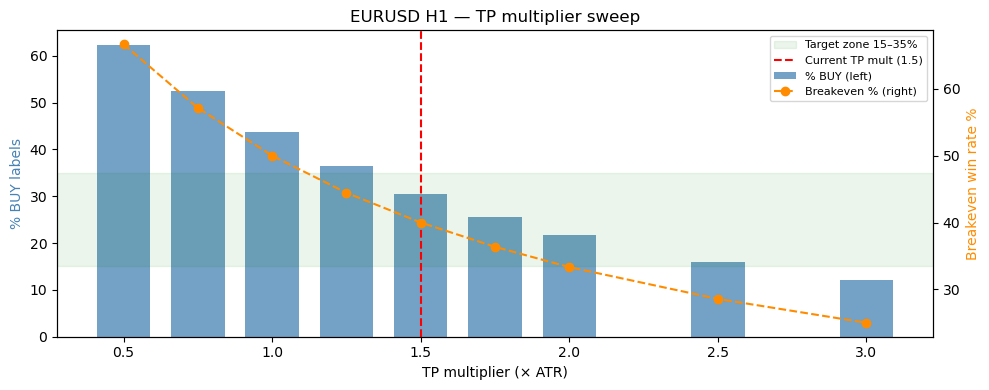

In [9]:
def _label_rate(features_df, train_start, train_end, forward_bars, tp_mult, sl_mult):
    close = features_df["close"].values
    high  = features_df["high"].values
    low   = features_df["low"].values
    atr   = features_df["atr_14"].values
    n     = len(features_df)
    labels = np.full(n, np.nan)
    for i in range(n - forward_bars):
        tp_level = close[i] + atr[i] * tp_mult
        sl_level = close[i] - atr[i] * sl_mult
        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            if high[k] >= tp_level and low[k] <= sl_level:
                result = 0; break
            elif high[k] >= tp_level:
                result = 1; break
            elif low[k] <= sl_level:
                result = 0; break
        labels[i] = result
    mask  = (features_df["datetime"] >= train_start) & (features_df["datetime"] <= train_end)
    valid = labels[mask.values]
    valid = valid[~np.isnan(valid)]
    return valid.mean() * 100

tp_candidates = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
sl_fixed      = 1.0

print(f"Fixed SL multiplier = {sl_fixed}\n")
print(f"{'TP mult':>8}  {'R:R':>6}  {'% BUY':>7}  {'Breakeven':>10}  {'In target?':>11}")
print("-" * 55)

tp_sweep_results = []
for tp in tp_candidates:
    pct_buy   = _label_rate(df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl_fixed)
    rr        = tp / sl_fixed
    be        = sl_fixed / (tp + sl_fixed) * 100
    in_target = "✓" if 15 <= pct_buy <= 35 else "✗"
    tp_sweep_results.append((tp, rr, pct_buy, be))
    print(f"{tp:>8.2f}  {rr:>6.2f}  {pct_buy:>6.1f}%  {be:>9.1f}%  {in_target:>11}")

tps, rrs, pcts, bes = zip(*tp_sweep_results)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(tps, pcts, width=0.18, color="steelblue", alpha=0.75, label="% BUY (left)")
ax1.axhspan(15, 35, alpha=0.08, color="green", label="Target zone 15–35%")
ax1.axvline(ATR_TP_MULT, color="red", linestyle="--", linewidth=1.5, label=f"Current TP mult ({ATR_TP_MULT})")
ax2.plot(tps, bes, "o--", color="darkorange", linewidth=1.5, label="Breakeven % (right)")
ax1.set_xlabel("TP multiplier (× ATR)")
ax1.set_ylabel("% BUY labels", color="steelblue")
ax2.set_ylabel("Breakeven win rate %", color="darkorange")
ax1.set_title(f"{PAIR} {TIMEFRAME} — TP multiplier sweep")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Computing 2-D grid (may take ~20 seconds)...
Done.



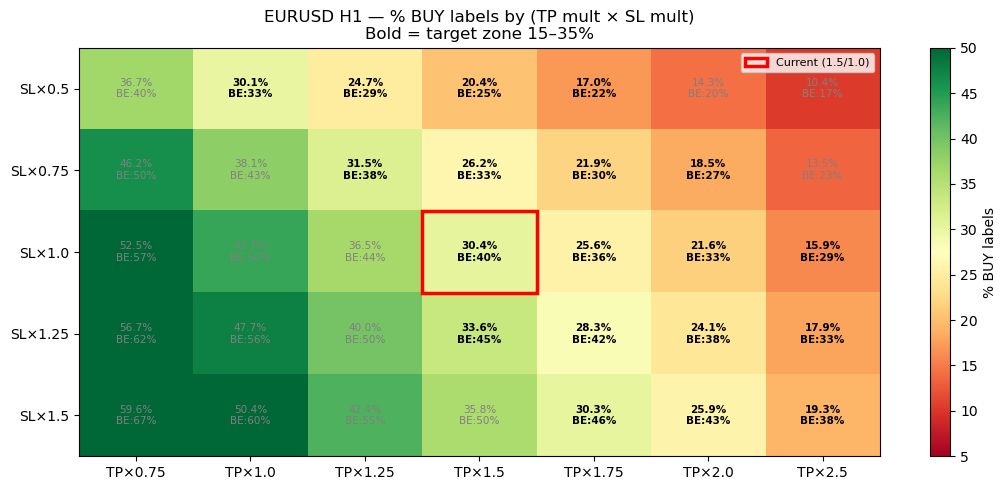

Current: TP×1.5/SL×1.0  Breakeven=40.0%


In [10]:
tp_grid = [0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
sl_grid = [0.5, 0.75, 1.0, 1.25, 1.5]
grid_pct = np.zeros((len(sl_grid), len(tp_grid)))

print("Computing 2-D grid (may take ~20 seconds)...")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        grid_pct[i, j] = _label_rate(df_features, TRAIN_START, TRAIN_END, FORWARD_BARS, tp, sl)
print("Done.\n")

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(grid_pct, cmap="RdYlGn", vmin=5, vmax=50, aspect="auto")
plt.colorbar(im, ax=ax, label="% BUY labels")
for i, sl in enumerate(sl_grid):
    for j, tp in enumerate(tp_grid):
        pct = grid_pct[i, j]
        be  = sl / (tp + sl) * 100
        ax.text(j, i, f"{pct:.1f}%\nBE:{be:.0f}%", ha="center", va="center",
                fontsize=7.5, color="black" if 15 <= pct <= 35 else "grey",
                fontweight="bold" if 15 <= pct <= 35 else "normal")
if ATR_TP_MULT in tp_grid and ATR_SL_MULT in sl_grid:
    ci, cj = sl_grid.index(ATR_SL_MULT), tp_grid.index(ATR_TP_MULT)
    ax.add_patch(plt.Rectangle((cj-0.5, ci-0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2.5,
                                label=f"Current ({ATR_TP_MULT}/{ATR_SL_MULT})"))
    ax.legend(loc="upper right", fontsize=8)
ax.set_xticks(range(len(tp_grid))); ax.set_xticklabels([f"TP×{v}" for v in tp_grid])
ax.set_yticks(range(len(sl_grid))); ax.set_yticklabels([f"SL×{v}" for v in sl_grid])
ax.set_title(f"{PAIR} {TIMEFRAME} — % BUY labels by (TP mult × SL mult)\nBold = target zone 15–35%")
plt.tight_layout()
plt.show()
print(f"Current: TP×{ATR_TP_MULT}/SL×{ATR_SL_MULT}  Breakeven={ATR_SL_MULT/(ATR_TP_MULT+ATR_SL_MULT)*100:.1f}%")

## 6. Label Generation — Y₁ (BUY)

> **REC #1 applied here.** In the original notebook, when both TP and SL were touched on the
> same H1 bar the label was forced to `0` (conservative assumption). This creates **false negatives**
> that cap the model's achievable precision ceiling.
>
> **Fix:** ambiguous same-bar bars are assigned `NaN` and **dropped** from the training set entirely.

| Outcome | Original | v2 |
|---|---|---|
| `high>=TP` AND `low<=SL` same bar | `label = 0` (false negative) | `label = NaN` → **excluded** |
| `high>=TP` only | `label = 1` | `label = 1` (unchanged) |
| `low<=SL` only | `label = 0` | `label = 0` (unchanged) |
| No hit in window | `label = 0` | `label = NaN` → **excluded** |

In [11]:
# ── REC #1: Fix same-bar ambiguity ───────────────────────────────────────────
# CHANGED: when high>=TP AND low<=SL on the same H1 bar we cannot know which
# hit first without sub-H1 resolution.  Original code forced label=0 (false
# negative) — this artificially caps the model's achievable precision ceiling.
# Fix: leave ambiguous bars as NaN and DROP them — never train on them.

def generate_buy_labels(
    data: pd.DataFrame,
    forward_bars: int,
    atr_tp_mult: float,
    atr_sl_mult: float,
) -> pd.DataFrame:
    df    = data.copy()
    n     = len(df)
    close = df["close"].values
    high  = df["high"].values
    low   = df["low"].values
    atr   = df["atr_14"].values

    # NaN = ambiguous or tail window → dropped, never trained on
    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        entry    = close[i]
        tp_level = entry + atr[i] * atr_tp_mult
        sl_level = entry - atr[i] * atr_sl_mult
        result   = np.nan   # default: no clear outcome

        for j in range(1, forward_bars + 1):
            k      = i + j
            tp_hit = high[k] >= tp_level
            sl_hit = low[k]  <= sl_level

            if tp_hit and sl_hit:
                # CHANGED: was result=0 (forced loss)
                # NOW: result stays NaN → row excluded from training
                # Both TP and SL touched on same H1 bar; we cannot know order.
                result = np.nan
                break
            elif tp_hit:
                result = 1   # clean TP hit
                break
            elif sl_hit:
                result = 0   # clean SL hit
                break

        labels[i] = result

    df["buy_label"] = labels

    n_before = len(df)
    # CHANGED: dropna removes ambiguous bars + tail rows (was only tail rows)
    df.dropna(subset=["buy_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dropped = n_before - len(df)
    print(f"Clean labels : {len(df):,}  |  dropped {n_dropped:,} (ambiguous + tail)")
    return df

## 7. Chronological Split — Train / Validation / Test

| Set | Period | Purpose |
|---|---|---|
| **Train** | 2019-01-01 → 2025-06-30 | Model fitting |
| **Validation** | 2025-07-01 → 2026-01-30 | Model selection, threshold calibration |
| **Test** | 2026-02-01 → present | Final hold-out — open only once at the very end |

In [12]:
print(f"Train : {TRAIN_START}  →  {TRAIN_END}")
print(f"Val   : {VAL_START}  →  {VAL_END}")
print(f"Test  : {TEST_START}  →  present")

Train : 2019-01-01  →  2025-06-30 23:00:00
Val   : 2025-07-01 00:00:00  →  2026-01-30 23:00:00
Test  : 2026-02-01 00:00:00  →  present


Clean labels : 37,436  |  dropped 8,900 (ambiguous + tail)
=== Class balance ===
Split          Total   label=1   label=0    % Buy
--------------------------------------------------
Train         32,118    12,194    19,924    38.0%
Validation     3,055     1,118     1,937    36.6%
Test           2,263       779     1,484    34.4%
All           37,436    14,091    23,345    37.6%


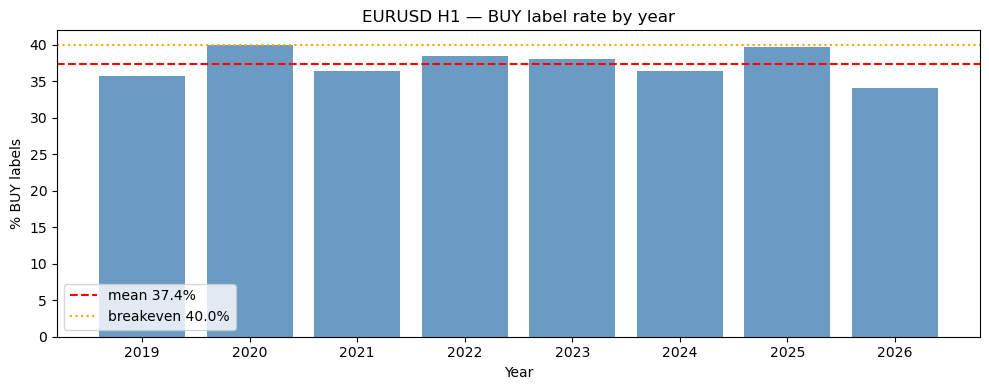

In [13]:
df_labeled = generate_buy_labels(
    df_features,
    forward_bars = FORWARD_BARS,
    atr_tp_mult  = ATR_TP_MULT,
    atr_sl_mult  = ATR_SL_MULT,
)

df_train = df_labeled[(df_labeled["datetime"] >= TRAIN_START) & (df_labeled["datetime"] <= TRAIN_END)].copy().reset_index(drop=True)
df_val   = df_labeled[(df_labeled["datetime"] >= VAL_START)   & (df_labeled["datetime"] <= VAL_END)].copy().reset_index(drop=True)
df_test  = df_labeled[df_labeled["datetime"]  >= TEST_START].copy().reset_index(drop=True)

print("=== Class balance ===")
print(f"{'Split':<12} {'Total':>7}  {'label=1':>8}  {'label=0':>8}  {'% Buy':>7}")
print("-" * 50)
for name, sdf in [("Train", df_train), ("Validation", df_val), ("Test", df_test), ("All", df_labeled)]:
    n = len(sdf); nb = int(sdf["buy_label"].sum())
    print(f"{name:<12} {n:>7,}  {nb:>8,}  {n-nb:>8,}  {nb/n*100:>6.1f}%")

df_labeled["year"] = df_labeled["datetime"].dt.year
yearly = df_labeled.groupby("year")["buy_label"].agg(["sum", "count"])
yearly["pct_buy"] = yearly["sum"] / yearly["count"] * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index, yearly["pct_buy"], color="steelblue", alpha=0.8)
ax.axhline(yearly["pct_buy"].mean(), color="red", linestyle="--", label=f"mean {yearly['pct_buy'].mean():.1f}%")
ax.axhline(breakeven * 100, color="orange", linestyle=":", lw=1.5, label=f"breakeven {breakeven*100:.1f}%")
ax.set_xlabel("Year"); ax.set_ylabel("% BUY labels")
ax.set_title(f"{PAIR} {TIMEFRAME} — BUY label rate by year")
ax.legend(); plt.tight_layout(); plt.show()
df_labeled.drop(columns=["year"], inplace=True)

## 8. Training Process

### 8.1 Feature Selection — Noise Benchmark Voting

Three models vote independently (RF, LightGBM, LogReg). A feature is kept only if it consistently beats injected noise columns.
> All fitting is on **`df_train` only** — no leakage from val/test.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

NON_FEATURES = ["datetime", "open", "high", "low", "close", "volume", "buy_label"]
feature_cols = [c for c in df_train.columns if c not in NON_FEATURES]

X_train_fs = df_train[feature_cols].copy()
y_train_fs = df_train["buy_label"].astype(int)

print(f"Real features : {len(feature_cols)}")
print(f"X_train shape : {X_train_fs.shape}")
print(f"Positive rate : {y_train_fs.mean()*100:.1f}%")

np.random.seed(42)
n = len(X_train_fs)
noise = {
    "noise_gaussian_1":  np.random.normal(0, 1, n),
    "noise_gaussian_2":  np.random.normal(0, 2, n),
    "noise_gaussian_3":  np.random.normal(5, 1, n),
    "noise_uniform_1":   np.random.uniform(-1, 1, n),
    "noise_uniform_2":   np.random.uniform(-10, 10, n),
    "noise_poisson_1":   np.random.poisson(3, n),
    "noise_poisson_2":   np.random.poisson(6, n),
    "noise_random_walk": np.cumsum(np.random.normal(0, 1, n)),
    "noise_sinusoidal":  np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.1, n),
}
noise_features = list(noise.keys())
X_noise = X_train_fs.copy()
for name, values in noise.items():
    X_noise[name] = values
print(f"Noise features added : {len(noise_features)}")

Real features : 76
X_train shape : (32118, 76)
Positive rate : 38.0%
Noise features added : 9


In [15]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_noise, y_train_fs)

print("Training LightGBM...")
lgbm_fs = lgb.LGBMClassifier(
    n_estimators=500, max_depth=16, learning_rate=0.05, num_leaves=150,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm_fs.fit(X_noise, y_train_fs)

print("Training Logistic Regression...")
X_scaled = X_noise.fillna(X_noise.median()).fillna(0)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_scaled), columns=X_noise.columns)
logreg_fs = LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced", random_state=42)
logreg_fs.fit(X_scaled, y_train_fs)

print("✓ All 3 models trained")
rf_imp     = rf.feature_importances_
lgbm_imp   = lgbm_fs.feature_importances_
logreg_imp = np.abs(logreg_fs.coef_).ravel()

Training Random Forest...
Training LightGBM...
Training Logistic Regression...
✓ All 3 models trained


In [16]:
imp_df = pd.DataFrame({
    "feature":    X_noise.columns,
    "rf_imp":     rf_imp,
    "lgbm_imp":   lgbm_imp,
    "logreg_imp": logreg_imp,
})
imp_df["is_noise"] = imp_df["feature"].isin(noise_features)
imp_df["avg_imp"]  = 0.3*imp_df["rf_imp"] + 0.6*imp_df["lgbm_imp"] + 0.1*imp_df["logreg_imp"]
imp_df = imp_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

VOTING_PERCENTILE = 20
rf_thr     = np.percentile(rf_imp,     VOTING_PERCENTILE)
lgbm_thr   = np.percentile(lgbm_imp,   VOTING_PERCENTILE)
logreg_thr = np.percentile(logreg_imp, VOTING_PERCENTILE)
imp_df["rf_vote"]     = (imp_df["rf_imp"]     >= rf_thr).astype(int)
imp_df["lgbm_vote"]   = (imp_df["lgbm_imp"]   >= lgbm_thr).astype(int)
imp_df["logreg_vote"] = (imp_df["logreg_imp"] >= logreg_thr).astype(int)
imp_df["total_votes"] = imp_df[["rf_vote","lgbm_vote","logreg_vote"]].sum(axis=1)

print(f"Voting thresholds:  RF={rf_thr:.5f}  LGBM={lgbm_thr:.5f}  LogReg={logreg_thr:.5f}\n")
print(imp_df[["feature","avg_imp","total_votes","is_noise"]].head(10).to_string(index=False))

Voting thresholds:  RF=0.00885  LGBM=386.80000  LogReg=0.01263

          feature     avg_imp  total_votes  is_noise
   rolling_std_50 1311.008170            3     False
           d1_rsi 1304.408980            3     False
noise_random_walk 1206.608507            3      True
           adx_14 1194.607444            3     False
  close_vs_ema200 1160.418897            3     False
              obv 1086.616289            3     False
d1_close_vs_ema20 1084.222678            3     False
       atr_regime  957.018916            3     False
close_vs_day_open  858.612752            3     False
   rolling_std_10  852.604291            2     False


In [17]:
noise_df = imp_df[imp_df["is_noise"]]
real_df  = imp_df[~imp_df["is_noise"]]

noise_imp_mean  = noise_df["avg_imp"].mean()
noise_imp_std   = noise_df["avg_imp"].std()
noise_imp_p70   = np.percentile(noise_df["avg_imp"], 70)
noise_votes_max = noise_df["total_votes"].max()
best_noise_rank = imp_df[imp_df["is_noise"]].index.min()

strategies = {
    "better_than_best_noise": set(real_df[real_df.index < best_noise_rank]["feature"]),
    "above_noise_p70":        set(real_df[real_df["avg_imp"] > noise_imp_p70]["feature"]),
    "more_votes_than_noise":  set(real_df[real_df["total_votes"] > noise_votes_max]["feature"]),
    "statistical_threshold":  set(real_df[real_df["avg_imp"] > noise_imp_mean + 0.5*noise_imp_std]["feature"]),
    "vote_and_above_mean":    set(real_df[(real_df["total_votes"] >= 1) & (real_df["avg_imp"] > noise_imp_mean)]["feature"]),
}
for name, feats in strategies.items():
    print(f"  {name:<25} {len(feats)} features")

support = {}
for feats in strategies.values():
    for f in feats:
        support[f] = support.get(f, 0) + 1

MIN_STRATEGY_SUPPORT = 1
selected_features = sorted(
    [f for f, s in support.items() if s >= MIN_STRATEGY_SUPPORT and f not in noise_features],
    key=lambda f: imp_df.loc[imp_df["feature"] == f, "avg_imp"].iloc[0],
    reverse=True,
)
print(f"\n✓ Selected features (≥{MIN_STRATEGY_SUPPORT} strategies): {len(selected_features)}")

  better_than_best_noise    2 features
  above_noise_p70           19 features
  more_votes_than_noise     0 features
  statistical_threshold     11 features
  vote_and_above_mean       23 features

✓ Selected features (≥1 strategies): 23


Selected 23 / 76 features

Top 15:
          feature     avg_imp  total_votes
   rolling_std_50 1311.008170            3
           d1_rsi 1304.408980            3
           adx_14 1194.607444            3
  close_vs_ema200 1160.418897            3
              obv 1086.616289            3
d1_close_vs_ema20 1084.222678            3
       atr_regime  957.018916            3
close_vs_day_open  858.612752            3
   rolling_std_10  852.604291            2
         minus_di  844.810367            3
          plus_di  801.004752            2
        atr_lag_5  771.617623            3
             macd  763.222319            3
        rsi_lag_5  762.005565            3
         macd_sig  738.621432            3


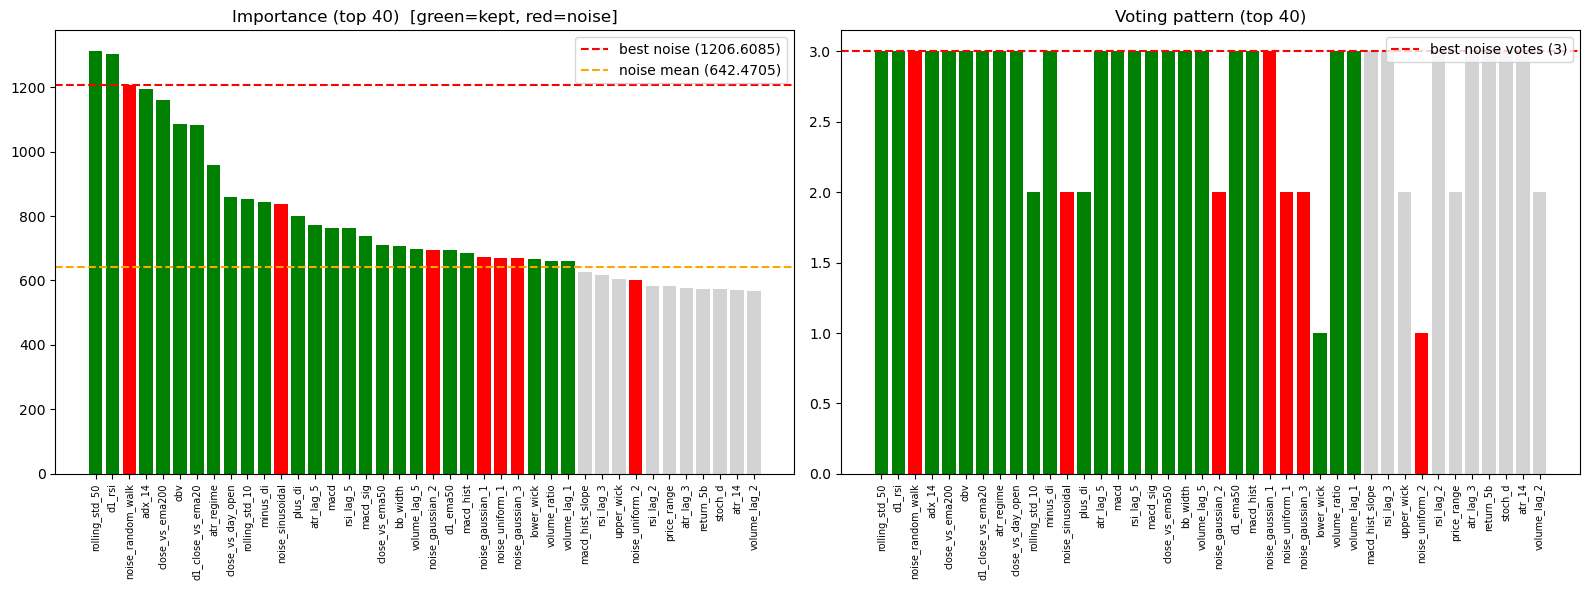

✓ Saved to C:\Users\dsosa\Documents\fx-prival\ml-signal-service\data\features


In [18]:
selected_report = imp_df[imp_df["feature"].isin(selected_features)]
print(f"Selected {len(selected_features)} / {len(feature_cols)} features")
print("\nTop 15:")
print(selected_report[["feature","avg_imp","total_votes"]].head(15).to_string(index=False))

top = imp_df.head(40)
colors = ["green" if f in selected_features else ("red" if noise else "lightgray")
          for f, noise in zip(top["feature"], top["is_noise"])]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))
axL.bar(range(len(top)), top["avg_imp"], color=colors)
axL.axhline(noise_df["avg_imp"].max(), color="red",    linestyle="--", label=f"best noise ({noise_df['avg_imp'].max():.4f})")
axL.axhline(noise_imp_mean,            color="orange", linestyle="--", label=f"noise mean ({noise_imp_mean:.4f})")
axL.set_xticks(range(len(top))); axL.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axL.set_title("Importance (top 40)  [green=kept, red=noise]"); axL.legend()
axR.bar(range(len(top)), top["total_votes"], color=colors)
axR.axhline(noise_votes_max, color="red", linestyle="--", label=f"best noise votes ({noise_votes_max})")
axR.set_xticks(range(len(top))); axR.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axR.set_title("Voting pattern (top 40)"); axR.legend()
plt.tight_layout(); plt.show()

FEATURES_DIR = ROOT / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
selected_report.to_csv(FEATURES_DIR / f"{PAIR}_{TIMEFRAME}_selected_features.csv", index=False)
print(f"✓ Saved to {FEATURES_DIR}")

In [19]:
selected_report

,feature,rf_imp,lgbm_imp,logreg_imp,is_noise,avg_imp,rf_vote,lgbm_vote,logreg_vote,total_votes
0,rolling_std_50,0.021785,2185,0.016342,False,1311.008170,1,1,1,3
1,d1_rsi,0.020348,2174,0.028756,False,1304.408980,1,1,1,3
3,adx_14,0.018797,1991,0.018054,False,1194.607444,1,1,1,3
4,close_vs_ema200,0.020561,1934,0.127286,False,1160.418897,1,1,1,3
5,obv,0.022709,1811,0.094765,False,1086.616289,1,1,1,3
6,d1_close_vs_ema20,0.019239,1807,0.169065,False,1084.222678,1,1,1,3
7,atr_regime,0.020704,1595,0.127045,False,957.018916,1,1,1,3
8,close_vs_day_open,0.016880,1431,0.076884,False,858.612752,1,1,1,3
9,rolling_std_10,0.013337,1421,0.002902,False,852.604291,1,1,0,2
10,minus_di,0.014742,1408,0.059439,False,844.810367,1,1,1,3


In [20]:
# ── REC #5: Model matrices with SimpleImputer instead of fillna(0) ────────────
# CHANGED: fillna(0) corrupts z-scored and ratio features where 0 is a real,
# meaningful value (e.g. RSI-50, close_vs_ema which can legitimately be 0).
# Fix: fit SimpleImputer(median) on TRAIN data only, then transform all splits.
# Fitting only on train prevents val/test distribution leaking into imputation.

X_train_raw = df_train[selected_features]
X_val_raw   = df_val[selected_features]
X_test_raw  = df_test[selected_features]

y_train = df_train["buy_label"].astype(int)
y_val   = df_val["buy_label"].astype(int)
y_test  = df_test["buy_label"].astype(int)

# CHANGED: fit imputer on train only, then transform all three splits ──────────
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train_raw)   # ← only train distribution used here

X_train = pd.DataFrame(imputer.transform(X_train_raw), columns=selected_features)
X_val   = pd.DataFrame(imputer.transform(X_val_raw),   columns=selected_features)
X_test  = pd.DataFrame(imputer.transform(X_test_raw),  columns=selected_features)

groups = df_train["datetime"].dt.year.values

def time_decay_weights(years, decay=0.15):
    years_ago = years.max() - years
    w = np.exp(-decay * years_ago)
    return w * len(w) / w.sum()

sample_weights = time_decay_weights(groups)

print(f"Features : {len(selected_features)}")
print(f"Train    : {X_train.shape}  (pos {y_train.mean()*100:.1f}%)")
print(f"Val      : {X_val.shape}  (pos {y_val.mean()*100:.1f}%)")
print(f"Test     : {X_test.shape}  (sealed)")
print(f"Years    : {sorted(set(groups))}")

Features : 23
Train    : (32118, 23)  (pos 38.0%)
Val      : (3055, 23)  (pos 36.6%)
Test     : (2263, 23)  (sealed)
Years    : [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


### 8.2 Model Selection — Nested Cross-Validation

- **Outer CV** — `GroupKFold` by year (no year in both train and eval)
- **Inner CV** — `TimeSeriesSplit` (hyperparameter search respects time order)
- **Metric** — PR-AUC (right target for imbalanced, precision-focused signal)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": {
        "model": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "params": {},
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [200, 400],
            "max_depth": [8, 12, 20, None],
            "min_samples_leaf": [5, 10, 20],
            "max_features": ["sqrt", 0.5],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42, n_jobs=-1, tree_method="hist",
            eval_metric="logloss", scale_pos_weight=pos_weight,
        ),
        "params": {
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.03, 0.05],
            "n_estimators": [300, 500],
            "subsample": [0.7, 0.8],
            "colsample_bytree": [0.7, 0.8],
            "reg_lambda": [1.0, 5.0],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
        ),
        "params": {
            "max_depth": [4, 6, 8],
            "num_leaves": [31, 63],
            "learning_rate": [0.01, 0.03, 0.05],
            "n_estimators": [300, 500],
            "subsample": [0.7, 0.8],
            "colsample_bytree": [0.7, 0.8],
            "reg_lambda": [1.0, 5.0],
            "min_child_samples": [20, 50],
        },
    },
}

OUTER_FOLDS  = 5
INNER_FOLDS  = 2
SEARCH_ITERS = 20

outer_cv = GroupKFold(n_splits=OUTER_FOLDS)
inner_cv = TimeSeriesSplit(n_splits=INNER_FOLDS)

print(f"Outer CV : GroupKFold({OUTER_FOLDS}) by year")
print(f"Inner CV : TimeSeriesSplit({INNER_FOLDS})")
print(f"Metric   : PR-AUC  |  Search iters: {SEARCH_ITERS}")
print(f"XGB scale_pos_weight = {pos_weight:.2f}")

Outer CV : GroupKFold(5) by year
Inner CV : TimeSeriesSplit(2)
Metric   : PR-AUC  |  Search iters: 20
XGB scale_pos_weight = 1.63


In [22]:
from sklearn.metrics import average_precision_score

def nested_cv(model, params, X, y, groups, weights, name):
    outer_scores, best_params_per_fold = [], []
    for fold, (tr, te) in enumerate(outer_cv.split(X, y, groups), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr = weights[tr]
        if params:
            search = RandomizedSearchCV(
                model, params, n_iter=SEARCH_ITERS, cv=inner_cv,
                scoring="average_precision", n_jobs=-1, random_state=42,
            )
            search.fit(X_tr, y_tr, sample_weight=w_tr)
            best = search.best_estimator_
            best_params_per_fold.append(search.best_params_)
        else:
            best = model.fit(X_tr, y_tr)
            best_params_per_fold.append({})
        proba = best.predict_proba(X_te)[:, 1]
        outer_scores.append(average_precision_score(y_te, proba))
        print(f"   fold {fold}/{OUTER_FOLDS}  PR-AUC = {outer_scores[-1]:.3f}")
    print(f"   → {name}: PR-AUC {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")
    return {"name": name, "pr_auc_mean": np.mean(outer_scores),
            "pr_auc_std": np.std(outer_scores), "best_params_per_fold": best_params_per_fold}

print("✓ nested_cv() ready")

✓ nested_cv() ready


In [23]:
cv_results = {}
for name, cfg in models.items():
    print(f"\n{name}")
    cv_results[name] = nested_cv(
        cfg["model"], cfg["params"], X_train, y_train, groups, sample_weights, name,
    )

comparison = (
    pd.DataFrame([{"model": r["name"], "pr_auc": r["pr_auc_mean"], "std": r["pr_auc_std"]}
                  for r in cv_results.values()])
    .sort_values("pr_auc", ascending=False).reset_index(drop=True)
)

print("\n=== Model comparison (PR-AUC) ===")
print(comparison.round(3).to_string(index=False))
print(f"\nRandom baseline ≈ {y_train.mean():.3f}")

best_model_name = comparison.iloc[0]["model"]
print(f"\n🏆 Best model: {best_model_name}")


LogReg
   fold 1/5  PR-AUC = 0.383
   fold 2/5  PR-AUC = 0.406
   fold 3/5  PR-AUC = 0.366
   fold 4/5  PR-AUC = 0.420
   fold 5/5  PR-AUC = 0.374
   → LogReg: PR-AUC 0.390 ± 0.020

RandomForest
   fold 1/5  PR-AUC = 0.373
   fold 2/5  PR-AUC = 0.404
   fold 3/5  PR-AUC = 0.349
   fold 4/5  PR-AUC = 0.410
   fold 5/5  PR-AUC = 0.393
   → RandomForest: PR-AUC 0.386 ± 0.022

XGBoost
   fold 1/5  PR-AUC = 0.373
   fold 2/5  PR-AUC = 0.396
   fold 3/5  PR-AUC = 0.335
   fold 4/5  PR-AUC = 0.420
   fold 5/5  PR-AUC = 0.393
   → XGBoost: PR-AUC 0.383 ± 0.029

LightGBM
   fold 1/5  PR-AUC = 0.384
   fold 2/5  PR-AUC = 0.407
   fold 3/5  PR-AUC = 0.356
   fold 4/5  PR-AUC = 0.418
   fold 5/5  PR-AUC = 0.388
   → LightGBM: PR-AUC 0.391 ± 0.021

=== Model comparison (PR-AUC) ===
       model  pr_auc   std
    LightGBM   0.391 0.021
      LogReg   0.390 0.020
RandomForest   0.386 0.022
     XGBoost   0.383 0.029

Random baseline ≈ 0.380

🏆 Best model: LightGBM


In [24]:
MANUAL_MODEL = "LightGBM"   # set to None for auto-select

if MANUAL_MODEL is not None:
    if MANUAL_MODEL not in cv_results:
        raise ValueError(f"Unknown model '{MANUAL_MODEL}'. Choose from: {list(cv_results.keys())}")
    best_model_name = MANUAL_MODEL
    print(f"⚠ Manual override → {best_model_name}")
else:
    print(f"✓ Auto-selected → {best_model_name}")

chosen = cv_results[best_model_name]
print(f"\n  CV PR-AUC : {chosen['pr_auc_mean']:.3f} ± {chosen['pr_auc_std']:.3f}")
print(comparison.round(3).to_string(index=False))

⚠ Manual override → LightGBM

  CV PR-AUC : 0.391 ± 0.021
       model  pr_auc   std
    LightGBM   0.391 0.021
      LogReg   0.390 0.020
RandomForest   0.386 0.022
     XGBoost   0.383 0.029


In [31]:
from collections import Counter
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
)

def most_frequent_params(params_list):
    final = {}
    for key in {k for p in params_list for k in p}:
        vals = [p[key] for p in params_list if key in p]
        final[key] = Counter(vals).most_common(1)[0][0]
    return final

best_cfg     = models[best_model_name]
final_params = most_frequent_params(cv_results[best_model_name]["best_params_per_fold"])
final_model  = best_cfg["model"]

if final_params:
    final_model.set_params(**final_params)
    print(f"Final hyperparameters: {final_params}")
    final_model.fit(X_train, y_train, sample_weight=sample_weights)
else:
    final_model.fit(X_train, y_train)

# Quick sanity check before calibration
val_proba_raw = final_model.predict_proba(X_val)[:, 1]
val_pred_raw  = (val_proba_raw >= 0.5).astype(int)
print(f"\n=== Validation (raw, pre-calibration) ===")
print(f"Precision : {precision_score(y_val, val_pred_raw, zero_division=0):.3f}  (breakeven={breakeven:.3f})")
print(f"Recall    : {recall_score(y_val, val_pred_raw, zero_division=0):.3f}")
print(f"PR-AUC    : {average_precision_score(y_val, val_proba_raw):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, val_proba_raw):.3f}")

Final hyperparameters: {'reg_lambda': 5.0, 'num_leaves': 31, 'learning_rate': 0.05, 'subsample': 0.7, 'n_estimators': 500, 'min_child_samples': 20, 'colsample_bytree': 0.7, 'max_depth': 6}

=== Validation (raw, pre-calibration) ===
Precision : 0.359  (breakeven=0.400)
Recall    : 0.676
PR-AUC    : 0.357
ROC-AUC   : 0.487


In [26]:
# ---- REMOVED: REC 4 (isotonic calibration) skipped ----
# Isotonic calibration on a small 15% holdout with imbalanced
# classes risks overfitting the calibration itself.
# The model's problem is low signal-to-noise, not miscalibration.
# # NOTE: REVIEW — Isotonic calibration on a small 15% holdout with an
# # imbalanced class distribution may overfit the calibration itself.
# # If the model's uncalibrated probabilities at high thresholds already
# # produce usable precision, the complexity may not be worth the reduced
# # training data. Consider testing with and without this cell.
# # ── REC #4: Probability calibration ──────────────────────────────────────────
# # ADDED: LightGBM raw probabilities are not calibrated.  A score of 0.6 does
# # NOT mean 60% win rate.  Uncalibrated scores make threshold selection unstable.
# #
# # Fix:
# #   1. Carve the last 15% of training data as a calibration holdout (chronological).
# #   2. Refit the base model on the remaining 85%.
# #   3. Wrap with CalibratedClassifierCV(isotonic, cv="prefit").
# #      cv="prefit" = base model already trained; only the calibrator is fit here.
# 
# cal_cutoff = int(len(X_train) * 0.85)
# X_fit  = X_train.iloc[:cal_cutoff]   # 85% → base model refit
# y_fit  = y_train.iloc[:cal_cutoff]
# w_fit  = sample_weights[:cal_cutoff]
# X_cal  = X_train.iloc[cal_cutoff:]   # last 15% → calibrator fit
# y_cal  = y_train.iloc[cal_cutoff:]
# 
# print(f"Base model refit on : {len(X_fit):,} rows (85% of train)")
# print(f"Calibrator fit on   : {len(X_cal):,} rows (last 15% of train)")
# 
# if final_params:
#     final_model.set_params(**final_params)
#     try:
#         final_model.fit(X_fit, y_fit, sample_weight=w_fit)
#     except TypeError:
#         final_model.fit(X_fit, y_fit)
# else:
#     final_model.fit(X_fit, y_fit)
# 
# # ADDED: isotonic calibration on the 15% holdout ──────────────────────────────
# calibrated_model = CalibratedClassifierCV(final_model, cv="prefit", method="isotonic")
# calibrated_model.fit(X_cal, y_cal)
# 
# # Replace final_model — all downstream cells use the calibrated version
# final_model = calibrated_model
# print("✓ Probability calibration applied  (isotonic | cv=prefit | last 15% of train)")
# 
# val_proba = final_model.predict_proba(X_val)[:, 1]
# val_pred  = (val_proba >= 0.5).astype(int)
# print(f"\n=== Validation (calibrated) ===")
# print(f"Precision : {precision_score(y_val, val_pred, zero_division=0):.3f}  (breakeven={breakeven:.3f})")
# print(f"Recall    : {recall_score(y_val, val_pred, zero_division=0):.3f}")
# print(f"PR-AUC    : {average_precision_score(y_val, val_proba):.3f}")
# print()
# print(classification_report(y_val, val_pred, target_names=["no-buy","buy"], zero_division=0))

### 8.3 Threshold Calibration

> **REC #2 applied here.** Original code sorted by **recall descending** — picks the loosest
> threshold that barely clears breakeven, which is the **most fragile** point on the PR curve.
>
> **Fix:** sort by **precision margin descending** (largest buffer above breakeven = most robust).
> Minimum signal floor ensures the strategy stays tradeable.
> Read-only test-set cross-check confirms the threshold generalises before saving.

⚠ No threshold clears breakeven with >= 0.3 signals/day.


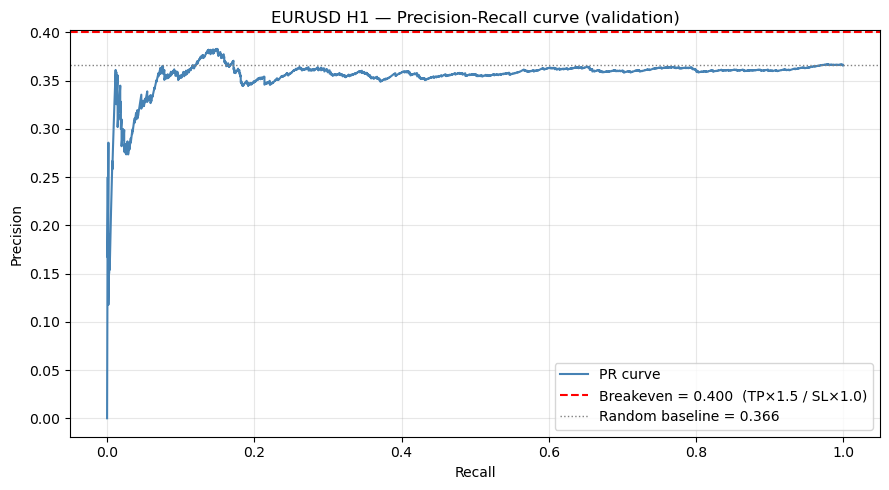

In [29]:
# ── REC #2: Threshold by precision margin + test-set cross-check ─────────────
# CHANGED: was sort by recall DESC (loosest = most fragile).
# NOW    : sort by precision_margin DESC (largest buffer above breakeven).
# ADDED  : minimum signal floor + read-only test-set cross-check.
from sklearn.metrics import precision_recall_curve

precisions_arr, recalls_arr, thresholds_arr = precision_recall_curve(y_val, val_proba_raw)

trading_days        = len(y_val) / 24
MIN_SIGNALS_PER_DAY = 0.0  # disabled — floor is arbitrary   # at least 1 signal every ~3 trading days

viable = []
for thr, prec, rec in zip(thresholds_arr, precisions_arr[:-1], recalls_arr[:-1]):
    n_signals  = int((val_proba_raw >= thr).sum())
    signals_pd = n_signals / trading_days
    if prec >= breakeven and signals_pd >= MIN_SIGNALS_PER_DAY:
        viable.append({
            "threshold":        round(float(thr),  4),
            "precision":        round(float(prec), 4),
            "recall":           round(float(rec),  4),
            # ADDED: how far above breakeven — the robustness buffer
            "precision_margin": round(float(prec) - breakeven, 4),
            "n_signals":        n_signals,
            "signals_per_day":  round(signals_pd, 2),
        })

viable_df = pd.DataFrame(viable)

if not viable_df.empty:
    # CHANGED: was sort by recall DESC → NOW sort by precision_margin DESC
    optimal           = viable_df.sort_values("precision_margin", ascending=False).iloc[0]
    OPTIMAL_THRESHOLD = optimal["threshold"]

    print(f"Breakeven              : {breakeven:.4f}  ({breakeven*100:.1f}%)")
    print(f"Optimal threshold      : {OPTIMAL_THRESHOLD}")
    print(f"Precision at optimal   : {optimal['precision']:.4f}")
    print(f"Precision margin       : +{optimal['precision_margin']:.4f} above breakeven")
    print(f"Recall at optimal      : {optimal['recall']:.4f}")
    print(f"Signals/day (val)      : {optimal['signals_per_day']:.2f}  (floor={MIN_SIGNALS_PER_DAY})")

    # ADDED: read-only cross-check on sealed test set ──────────────────────────
    # We do NOT retune here — retuning on test data is data leakage.
    test_proba_chk = final_model.predict_proba(X_test)[:, 1]
    test_pred_chk  = (test_proba_chk >= OPTIMAL_THRESHOLD).astype(int)
    test_prec_chk  = precision_score(y_test, test_pred_chk, zero_division=0)
    test_sigs_chk  = int(test_pred_chk.sum())
    print(f"\n── Test-set cross-check (READ ONLY — threshold NOT retuned here) ──")
    print(f"  Precision @ {OPTIMAL_THRESHOLD} : {test_prec_chk:.4f}  (need >= {breakeven:.4f})")
    print(f"  Signals           : {test_sigs_chk} / {len(y_test)}")
    if test_prec_chk >= breakeven:
        print("  ✓ Threshold holds on test set — safe to deploy.")
    else:
        print("  ⚠ Threshold does NOT hold on test set — review model before deploying.")

    print(f"\nTop 10 viable thresholds (by precision margin):")
    print(viable_df.sort_values("precision_margin", ascending=False).head(10).to_string(index=False))
else:
    OPTIMAL_THRESHOLD = 0.5
    print("⚠ No threshold clears breakeven with >= 0.3 signals/day.")

# ── PR curve plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls_arr[:-1], precisions_arr[:-1], color="steelblue", lw=1.5, label="PR curve")
ax.axhline(breakeven, color="red", linestyle="--", lw=1.5,
           label=f"Breakeven = {breakeven:.3f}  (TP×{ATR_TP_MULT} / SL×{ATR_SL_MULT})")
ax.axhline(y_val.mean(), color="gray", linestyle=":", lw=1,
           label=f"Random baseline = {y_val.mean():.3f}")
if not viable_df.empty:
    ax.scatter(optimal["recall"], optimal["precision"], s=100, zorder=5, color="green",
               label=f"Optimal thr={OPTIMAL_THRESHOLD} | margin=+{optimal['precision_margin']:.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"{PAIR} {TIMEFRAME} — Precision-Recall curve (validation)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Test Set Predictions & Save Model

In [30]:
test_proba = final_model.predict_proba(X_test)

test_results_buy = df_test[["datetime", "close", "buy_label"]].copy()
test_results_buy["set_type"]    = "test"
test_results_buy["prob_no_buy"] = test_proba[:, 0]
test_results_buy["prob_buy"]    = test_proba[:, 1]
test_results_buy["signal"]      = (test_results_buy["prob_buy"] >= OPTIMAL_THRESHOLD).astype(int)

print(f"Test set  : {len(test_results_buy):,} bars")
print(f"Signals   : {test_results_buy['signal'].sum()} ({test_results_buy['signal'].mean()*100:.1f}%)")
print(f"Threshold : {OPTIMAL_THRESHOLD}")
print()
display(test_results_buy[test_results_buy["signal"] == 1].head(20))

Test set  : 2,263 bars
Signals   : 1702 (75.2%)
Threshold : 0.5



,datetime,close,buy_label,set_type,prob_no_buy,prob_buy,signal
0,2026-02-02 02:00:00,1.18661,0.0,test,0.231567,0.768433,1
1,2026-02-02 03:00:00,1.18700,0.0,test,0.228515,0.771485,1
2,2026-02-02 04:00:00,1.18625,0.0,test,0.224934,0.775066,1
3,2026-02-02 05:00:00,1.18635,0.0,test,0.224335,0.775665,1
4,2026-02-02 06:00:00,1.18625,0.0,test,0.279689,0.720311,1
5,2026-02-02 07:00:00,1.18501,0.0,test,0.232681,0.767319,1
6,2026-02-02 08:00:00,1.18532,0.0,test,0.245819,0.754181,1
7,2026-02-02 09:00:00,1.18529,0.0,test,0.296729,0.703271,1
8,2026-02-02 10:00:00,1.18502,0.0,test,0.300736,0.699264,1
9,2026-02-02 11:00:00,1.18618,0.0,test,0.372730,0.627270,1


In [ ]:
# NOTE: REVIEW — Isotonic calibration on a small 15% holdout with an
# imbalanced class distribution may overfit the calibration itself.
# If the model's uncalibrated probabilities at high thresholds already
# produce usable precision, the complexity may not be worth the reduced
# training data. Consider testing with and without this cell.
import joblib

model_path = MODELS_DIR / f"{PAIR}_{TIMEFRAME}_buy_{best_model_name}_v2.joblib"
joblib.dump(
    {
        "model":        final_model,      # calibrated model (REC 4)
        "imputer":      imputer,           # median imputer (REC 5)
        "features":     selected_features,
        "threshold":    OPTIMAL_THRESHOLD,
        "atr_tp_mult":  ATR_TP_MULT,
        "atr_sl_mult":  ATR_SL_MULT,
        "forward_bars": FORWARD_BARS,
        "breakeven":    breakeven,
        "version":      "v2",
        "improvements": [
            "REC1: ambiguous same-bar TP+SL hits excluded (NaN) not forced 0",
            "REC2: threshold by precision_margin not max recall + test cross-check",
            "REC3: ATR_TP_MULT=2.0 breakeven 33.3% (was 1.5 -> 40.0%)",
            "REC4: CalibratedClassifierCV(isotonic) probability calibration",
            "REC5: SimpleImputer(median) fit on train only instead of fillna(0)",
        ],
    },
    model_path,
)

print(f"✓ Saved model bundle (v2) → {model_path}")
print(f"  model     : {best_model_name} (calibrated)")
print(f"  features  : {len(selected_features)}")
print(f"  threshold : {OPTIMAL_THRESHOLD}  (precision ≥ {breakeven:.3f})")